# Forecasting Exchange Rates using Time Series Analysis

Name: Ahmad Ali  
Batch: Data Science Weekday – Hyderabad  

In this assignment, we work on forecasting exchange rates using historical time series data. Exchange rates are very important in finance, international trade, business, and travel because they affect the value of currencies between countries. The dataset used in this assignment contains the exchange rate values between USD and Australian Dollar over a period of time. The goal of this assignment is to study the historical pattern of exchange rates and use forecasting techniques to predict future values.

Time series forecasting is different from normal machine learning because the order of data is important. Past values influence future values. In this assignment, we use two forecasting techniques: ARIMA and Exponential Smoothing. These models are widely used in financial forecasting because they help identify patterns such as trend, seasonality, and fluctuations in the data. At the end, both models are compared using error metrics to understand which model gives more accurate predictions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

## Importing Required Libraries

In this step, we import all the libraries needed for data analysis, forecasting, and visualization. Pandas is used to load and manage the dataset. NumPy is used for performing mathematical operations and calculations. Matplotlib and Seaborn are useful for plotting graphs and charts because graphs help us understand how exchange rates change over time.

We also import ARIMA and Exponential Smoothing models from the statsmodels library. These are the two forecasting techniques used in this assignment. ARIMA is useful when the data depends on past values and past errors, while Exponential Smoothing gives more importance to recent observations.

In addition, we import ACF and PACF plotting functions because they help us estimate the parameters needed for the ARIMA model. Finally, we import evaluation metrics such as MAE and RMSE because they help us measure how accurate the predictions are. Importing all required libraries at the beginning keeps the notebook organized and prevents errors later.

In [ ]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\exchange_rate.csv")

df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


## Loading the Dataset

In this step, we load the exchange rate dataset into the notebook. The dataset contains two main columns. The first column contains the date, and the second column contains the exchange rate values between USD and Australian Dollar. Loading the dataset is the first step because we need to understand what type of data we are working with.

After loading the dataset, we use the head() function to display the first few rows. This helps us confirm that the dataset has been loaded properly and that the column names are correct. It also helps us understand the structure of the data and identify any possible issues such as missing values or incorrect formatting.

Checking the dataset early is important because small mistakes in the beginning can create larger problems later. This step gives us a basic understanding of the data before we start preprocessing, plotting graphs, and building forecasting models.

In [ ]:
df.columns = ['Date', 'Exchange_Rate']

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.set_index('Date', inplace=True)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Exchange_Rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


,Exchange_Rate
Date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [ ]:
df.describe()

,Exchange_Rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


## Understanding Basic Statistics

The describe() function provides summary statistics of the exchange rate values. It shows the mean, minimum value, maximum value, standard deviation, and different percentiles.

The mean gives the average exchange rate value across the dataset. The minimum and maximum values show the lowest and highest exchange rates. The standard deviation tells us how much the exchange rate changes from the average value.

This information is useful because it helps us understand whether the exchange rate is stable or highly volatile. If the standard deviation is very high, it means the exchange rate changes a lot over time. Summary statistics are important because they give a quick overview of the data before we move to graphs and forecasting.

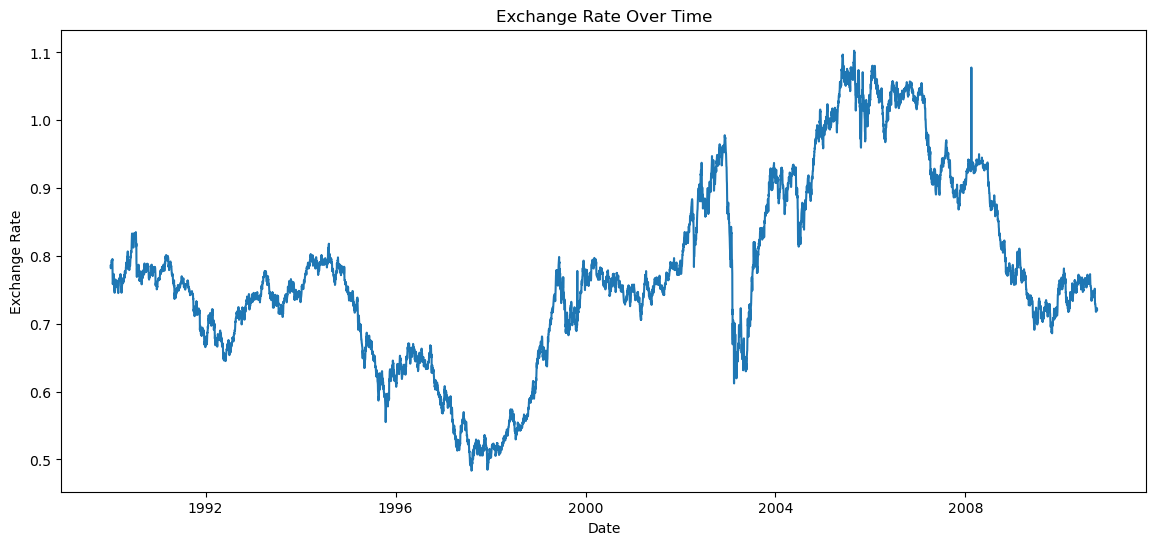

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df['Exchange_Rate'])
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

## Exploring the Time Series Data

This graph shows how the exchange rate changes over time. The x-axis represents the date, while the y-axis represents the exchange rate value. This visualization is very important because it helps us understand whether the exchange rate is increasing, decreasing, or fluctuating.

If the graph shows a steady upward movement, it means the exchange rate is increasing over time. If it moves downward, it means the exchange rate is decreasing. Sometimes, there may be sudden spikes or drops in the graph. These unusual changes may happen because of financial crises, government decisions, changes in interest rates, or global economic events.

By looking at this graph, we can also check whether the data contains seasonality or repeating patterns. Understanding these patterns is important because forecasting models work better when we know how the data behaves. This graph helps us decide whether we need more preprocessing before building forecasting models.

In [ ]:
df.isnull().sum()

Exchange_Rate    0
dtype: int64

In [ ]:
df = df.fillna(method='ffill')

C:\Users\tausi\AppData\Local\Temp\ipykernel_17396\569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


## Handling Missing Values

Missing values are common in real-world datasets. They can happen because of incomplete records, data collection problems, or technical issues. In time series analysis, missing values are especially important because forecasting models need continuous data to understand the pattern correctly.

In this assignment, we first check whether there are any missing values in the dataset. If missing values are present, we use the forward fill method to replace them. Forward fill uses the previous available value to fill the missing position. This method works well in time series data because nearby values are usually similar.

Handling missing values is important because models like ARIMA and Exponential Smoothing cannot work properly if the dataset has gaps. Filling missing values helps improve data quality and ensures that the forecasting models can learn from complete data. This step makes the dataset more reliable and prepares it for future analysis.

In [ ]:
train = df.iloc[:-30]
test = df.iloc[-30:]

## Splitting the Dataset

In time series forecasting, it is important to divide the data into training and testing sets. The training data is used to teach the forecasting model how the exchange rate behaves. The testing data is used to check how well the model predicts unseen future values.

In this assignment, we keep the last 30 observations for testing and use the remaining observations for training. This is important because forecasting models should always be evaluated on future values that they have not seen before.

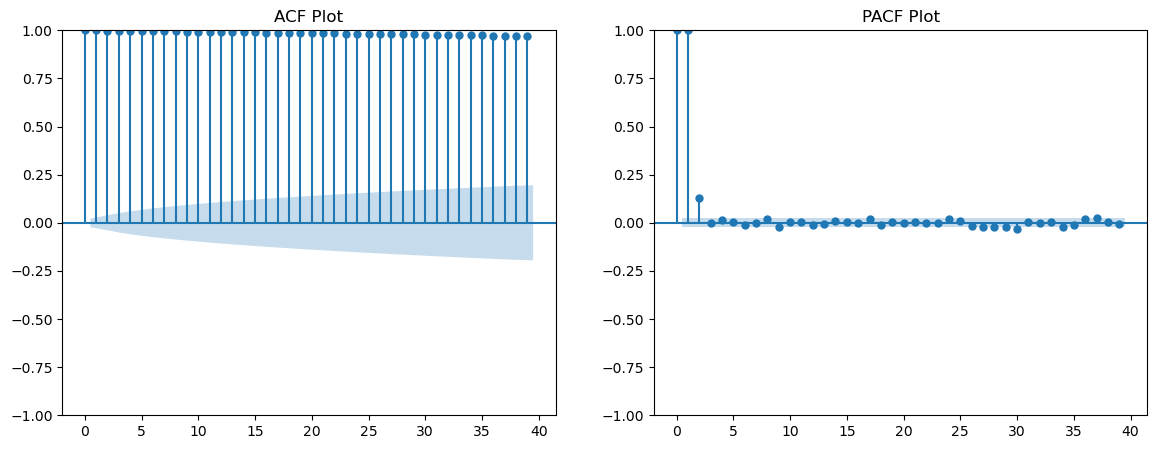

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(train['Exchange_Rate'], ax=axes[0])
axes[0].set_title('ACF Plot')

plot_pacf(train['Exchange_Rate'], ax=axes[1])
axes[1].set_title('PACF Plot')

plt.show()

## ACF and PACF Plots

ACF and PACF plots are important tools used to choose the parameters of the ARIMA model. The ACF plot shows how strongly the current value is related to previous values at different lag periods. The PACF plot shows the direct relationship between current and past values after removing the effect of intermediate lags.

These plots help us decide the values of p and q in the ARIMA model. The PACF plot is usually used to estimate p, while the ACF plot is used to estimate q. The value of d is usually chosen based on whether the data needs differencing to become stable.

Choosing the correct parameters is very important because the performance of ARIMA depends heavily on them. If the wrong values are chosen, the model may give poor predictions. These plots help us make better decisions and improve forecasting accuracy.

In [ ]:
arima_model = ARIMA(train['Exchange_Rate'], order=(1,1,1))
arima_result = arima_model.fit()

print(arima_result.summary())

C:\Users\tausi\anaconda3\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\tausi\anaconda3\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\tausi\anaconda3\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          Exchange_Rate   No. Observations:                 7558
Model:                 ARIMA(1, 1, 1)   Log Likelihood               27934.471
Date:                Wed, 22 Apr 2026   AIC                         -55862.942
Time:                        15:21:34   BIC                         -55842.152
Sample:                    01-01-1990   HQIC                        -55855.806
                         - 09-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1262      0.045     -2.783      0.005      -0.215      -0.037
ma.L1         -0.0056      0.045     -0.123      0.902      -0.095       0.083
sigma2      3.604e-05   9.99e-08    360.760      0.0

## Building the ARIMA Model

ARIMA stands for AutoRegressive Integrated Moving Average. It is one of the most commonly used models for time series forecasting. ARIMA uses past values, past errors, and differencing to predict future values.

The model has three parameters: p, d, and q. The value of p represents the number of past observations used, d represents the number of times differencing is applied, and q represents the number of past error terms used in prediction.

In this assignment, we use the parameter values (1,1,1). After fitting the model, we can see the summary table, which contains important information such as coefficient values and statistical details. This step is important because it creates the forecasting model that will later be used to predict future exchange rate values.

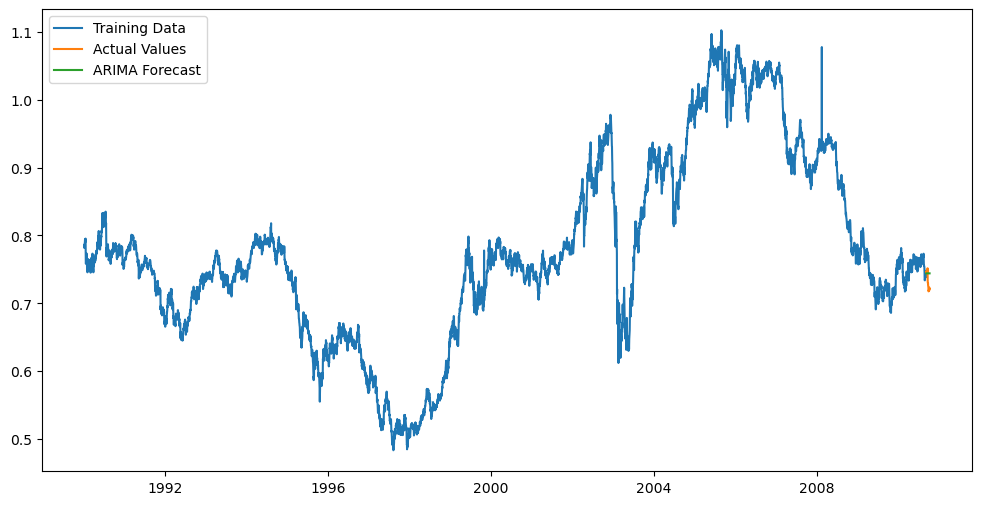

In [ ]:
arima_forecast = arima_result.forecast(steps=len(test))

plt.figure(figsize=(12,6))
plt.plot(train.index, train['Exchange_Rate'], label='Training Data')
plt.plot(test.index, test['Exchange_Rate'], label='Actual Values')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.show()

## ARIMA Forecast Visualization

This graph compares the actual exchange rate values with the forecasted values generated by the ARIMA model. The training data is shown to provide context, while the testing data and predicted values help us understand how accurate the model is.

If the forecast line is very close to the actual line, it means the model is performing well. If there is a large gap between the two lines, it means the model is not able to capture the pattern properly.

This graph is useful because visual comparison is often easier to understand than numbers alone. It helps us quickly identify whether the model is underpredicting or overpredicting the exchange rate values. This step is important because it shows whether the ARIMA model can be trusted for future forecasting.

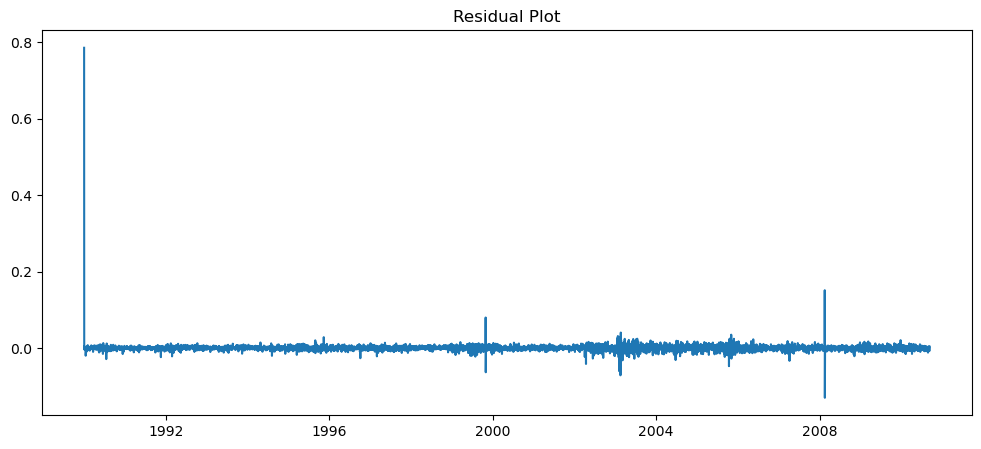

In [ ]:
residuals = arima_result.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title('Residual Plot')
plt.show()

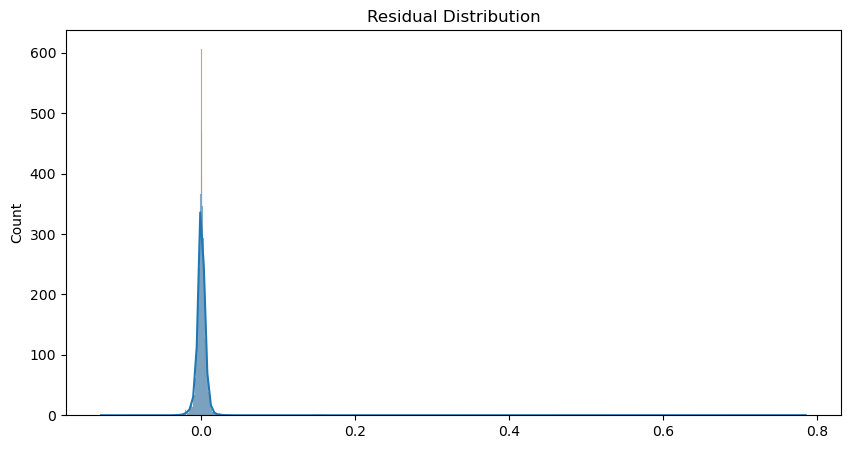

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

In [ ]:
exp_model = ExponentialSmoothing(
    train['Exchange_Rate'],
    trend='add',
    seasonal=None
)

exp_result = exp_model.fit()

exp_forecast = exp_result.forecast(len(test))

C:\Users\tausi\anaconda3\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


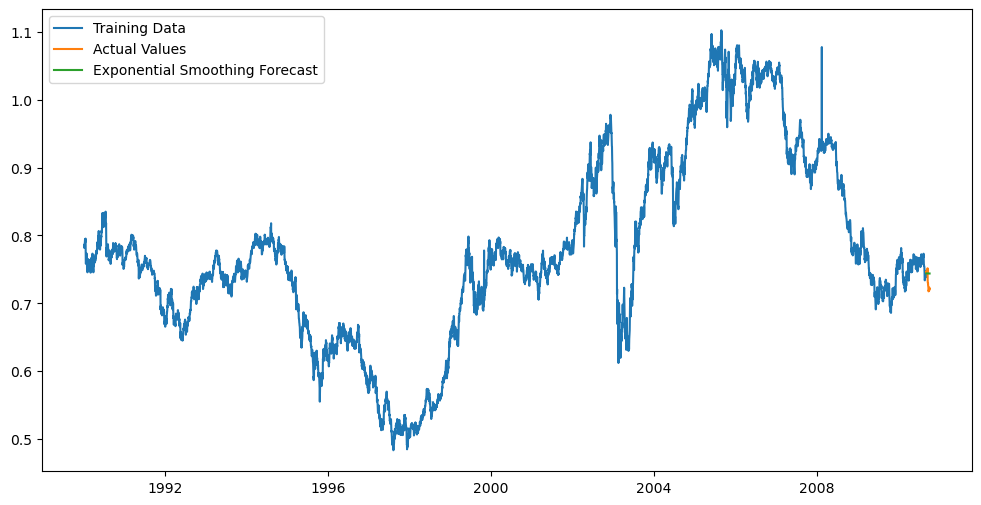

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Exchange_Rate'], label='Training Data')
plt.plot(test.index, test['Exchange_Rate'], label='Actual Values')
plt.plot(test.index, exp_forecast, label='Exponential Smoothing Forecast')
plt.legend()
plt.show()

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

arima_mae = mean_absolute_error(test['Exchange_Rate'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['Exchange_Rate'], arima_forecast))
arima_mape = mean_absolute_percentage_error(test['Exchange_Rate'], arima_forecast)

exp_mae = mean_absolute_error(test['Exchange_Rate'], exp_forecast)
exp_rmse = np.sqrt(mean_squared_error(test['Exchange_Rate'], exp_forecast))
exp_mape = mean_absolute_percentage_error(test['Exchange_Rate'], exp_forecast)

## Exponential Smoothing Model

Exponential Smoothing is another forecasting technique used for time series data. This method gives more importance to recent values and less importance to older values. This is useful because recent exchange rate values often have a stronger influence on future values.

In this assignment, we use additive trend Exponential Smoothing. After fitting the model, we generate predictions for the testing period. The forecast graph helps us compare the predicted values with the actual exchange rate values.

If the forecast line is close to the actual line, it means the model is performing well. Exponential Smoothing is often easier to understand and implement than ARIMA. However, sometimes ARIMA may perform better because it captures more detailed relationships in the data.

In [ ]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [arima_mae, exp_mae],
    'RMSE': [arima_rmse, exp_rmse],
    'MAPE': [arima_mape, exp_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.013495,0.016632,1.863221
1,Exponential Smoothing,0.013425,0.016500,1.853453


## Error Metrics and Model Comparison

To compare the performance of ARIMA and Exponential Smoothing, we use MAE, RMSE, and MAPE. MAE measures the average error between actual and predicted values. RMSE gives more importance to larger errors. MAPE shows the prediction error as a percentage.

Lower values for these metrics indicate better model performance. After calculating these metrics, we create a comparison table to see which model performs better.

If ARIMA has lower error values, it means ARIMA is more accurate for this dataset. If Exponential Smoothing has lower error values, then it means that model is better. This comparison is important because it helps us choose the most suitable forecasting model for future exchange rate prediction.

## Conclusion

In this assignment, we used ARIMA and Exponential Smoothing to forecast future exchange rates. We first explored the data, handled missing values, plotted graphs, and studied patterns in the exchange rate values. Then, we built forecasting models and compared their performance using error metrics.

The results show that both models are useful for forecasting, but one model may perform better depending on the dataset. ARIMA is usually stronger for capturing complex time-based relationships, while Exponential Smoothing is simpler and gives more importance to recent values.

This assignment helped us understand how time series forecasting works and why it is useful in finance, business, and currency exchange prediction. These forecasting methods can help companies and investors make better decisions in the future.